In [1]:
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
%matplotlib inline

from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

# loading mnist datasets

In [6]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.mnist.load_data()

In [7]:
type(X_train)

numpy.ndarray

In [8]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(60000, 28, 28) (10000, 28, 28) (60000,) (10000,)


## here (60000 --> no of images
          28 X 28 --> pixels size)

In [9]:
#printing the 10th image
print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

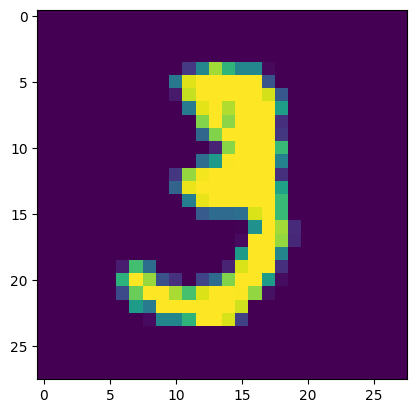

In [10]:
plt.imshow(X_train[10])
plt.show()

In [12]:
cv2_imshow(X_train[10])
plt.show()

In [13]:
np.unique(X_train)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [14]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [15]:
np.unique(y_test)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [19]:
## We can use this labels as such or we can also apply use One hot encoding

## make sure all the values of images or in the same dimensions
# here since it is a default dataset it has same dimensions

## To obtain same dimensions use ""Re Sizing methods""

## Scaling the values now (between 0 to 1)
X_train= X_train/255
X_test= X_test/255

In [29]:
## Building a Neural network

model= tf.keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50,activation="relu"),
    keras.layers.Dense(50,activation="relu"),
    keras.layers.Dense(10,activation="sigmoid")
])


In [30]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [31]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 50)                  │          39,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,310 (165.27 KB)

 Trainable params: 42,310 (165.27 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.fit(X_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8610 - loss: 0.4967
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9532 - loss: 0.1580
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9668 - loss: 0.1124
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9740 - loss: 0.0863
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9793 - loss: 0.0694
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9824 - loss: 0.0567
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9861 - loss: 0.0471
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9881 - loss: 0.0395
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9896 - loss: 0.0357
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9901 - loss: 0.0320


In [33]:
## accuarcy on the test data

loss, accuracy = model.evaluate(X_test,y_test)
print(accuracy)
print(loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9655 - loss: 0.1299
0.9672999978065491
0.12165975570678711


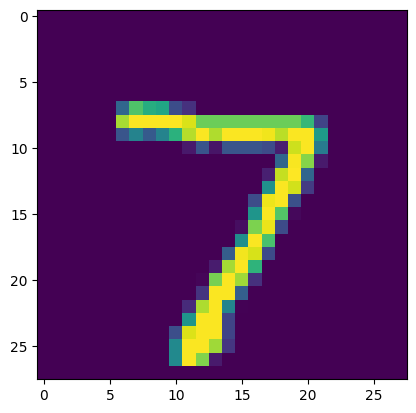

In [36]:
## first data point in data

plt.imshow(X_test[0])
plt.show()

In [37]:
print(y_test[0])

7


In [38]:
y_pred= model.predict(X_test)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[2.20715810e-06, 9.27899685e-03, 4.60576302e-05, ...,
        9.99999344e-01, 7.18369498e-04, 9.72364485e-01],
       [9.02541360e-05, 9.99657035e-01, 1.00000000e+00, ...,
        2.02564951e-08, 6.38106167e-02, 4.37296974e-03],
       [2.04871316e-03, 9.99780715e-01, 8.38172138e-02, ...,
        6.73765838e-01, 2.92531908e-01, 1.33711360e-02],
       ...,
       [6.43392717e-09, 1.14196861e-04, 3.26099858e-08, ...,
        7.98507929e-01, 7.73171902e-01, 9.85857666e-01],
       [2.08173773e-07, 2.25006396e-08, 4.71051392e-11, ...,
        1.10812884e-07, 5.40049195e-01, 6.05696596e-06],
       [4.17315634e-03, 1.73738517e-08, 3.13668388e-05, ...,
        8.67600602e-10, 3.64311645e-03, 5.66311061e-01]], dtype=float32)

In [39]:
print(y_pred.shape)

(10000, 10)


In [40]:
print(y_pred[0])

[2.2071581e-06 9.2789968e-03 4.6057630e-05 9.9185622e-01 9.6172016e-08
 2.0190591e-02 4.8007979e-13 9.9999934e-01 7.1836950e-04 9.7236449e-01]


In [42]:
## model.predict give prediction probability of each class for that specific data point

In [43]:
y_pred_list= np.argmax(y_pred[0]) ## first image

In [44]:
print(y_pred_list)

7


In [45]:
## converting prediction probability to class label for all test data points
y_pred_labels= [np.argmax(i) for i in y_pred]
print(y_pred_labels)

[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 9, 3, 1, 4, 1, 7, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 4, 4, 4, 9, 2, 5, 4, 7, 6, 7, 9, 0, 5, 8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1, 7, 1, 8, 2, 0, 4, 9, 9, 5, 5, 1, 5, 6, 0, 3, 4, 4, 6, 5, 4, 6, 5, 4, 5, 1, 4, 4, 7, 2, 3, 2, 7, 1, 8, 1, 8, 1, 8, 5, 0, 8, 9, 2, 5, 0, 1, 1, 1, 0, 9, 0, 3, 1, 6, 4, 3, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5, 9, 3, 9, 0, 3, 6, 5, 5, 7, 2, 2, 7, 1, 2, 8, 4, 1, 7, 3, 3, 8, 8, 7, 9, 2, 2, 4, 1, 5, 9, 8, 7, 2, 3, 0, 2, 4, 2, 4, 1, 9, 5, 7, 7, 2, 8, 2, 6, 8, 5, 7, 7, 9, 1, 8, 1, 8, 0, 3, 9, 1, 9, 9, 4, 1, 8, 2, 1, 2, 9, 7, 5, 9, 2, 6, 4, 1, 5, 8, 2, 9, 2, 0, 4, 0, 0, 2, 8, 4, 7, 1, 2, 4, 0, 2, 7, 4, 3, 3, 0, 0, 3, 1, 9, 6, 5, 2, 5, 9, 7, 9, 3, 0, 4, 2, 0, 7, 1, 1, 2, 1, 

In [46]:
# Confusion Matrix

conf_mat= confusion_matrix(y_test,y_pred_labels)
conf_mat

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 956,    0,    2,    2,    2,    3,    2,    1,    1,   11],
       [   0, 1118,    1,    5,    0,    0,    3,    1,    6,    1],
       [   4,    2,  955,   34,    7,    3,    1,   14,   11,    1],
       [   0,    0,    0,  994,    0,    3,    0,    6,    0,    7],
       [   0,    0,    4,    0,  960,    1,    2,    4,    3,    8],
       [   2,    0,    0,   13,    1,  870,    2,    0,    2,    2],
       [   3,    2,    1,    0,   12,    6,  932,    1,    1,    0],
       [   1,    1,    6,    3,    5,    0,    0,  992,    6,   14],
       [   1,    0,    1,   21,    4,    8,    5,    3,  925,    6],
       [   0,    2,    0,    5,   14,   10,    2,    4,    1,  971]],
      dtype=int32)>

Text(0.5, 47.7222222222222, 'Predicted Labels')

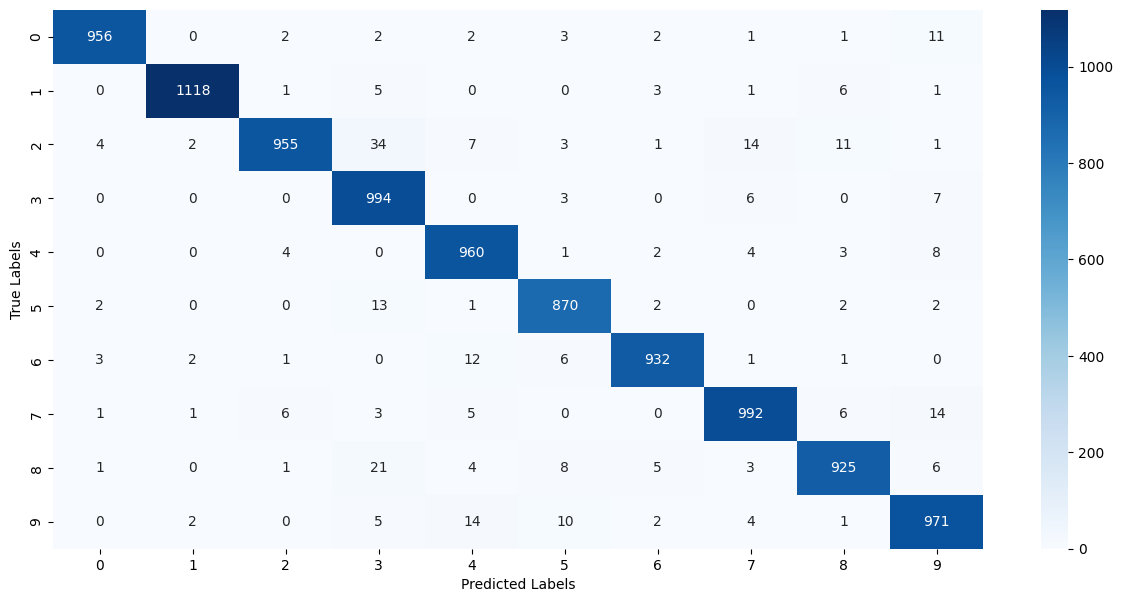

In [48]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

In [49]:
## building a predictive system

input_image_path=''
input_image= cv2.imread(input_image_path)
print(type(input_image))
cv2_imshow(input_image)
print(input_image.shape)
gray_scale= cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)
print(gray_scale.shape)
img_resize= cv2.resize(gray_scale, (28,28))
print(img_resize.shape)
cv2_imshow(img_resize)

## scaling the image
img_resize= img_resize/255

## reshape
img_reshape= np.reshape(img_resize, [1,28,28])


## input prediction
input_pred= model.predict(img_reshape)
input_pred_label= np.argmax(input_pred)
print(input_pred_label)

<bound method Kernel.raw_input of <google.colab._kernel.Kernel object at 0x7b27872b2110>>